# SFT Data Scaling & Empirical Learning Curve Analysis
### Masterarbeit: Automatische Übersetzung von Alltagssprache (AS) in Leichte Sprache (LS)

Dieses Notebook analysiert systematisch das **Skalierungsverhalten des Supervised Fine-Tuning (SFT)** Modells (`facebook/mbart-large-50` + LoRA) entlang der verfügbaren Trainingsdatenmenge:

$$\text{Trainingsfraktionen } F \in \{10\%, 25\%, 50\%, 75\%, 100\%\} \iff N \in \{65, 162, 323, 484, 646\} \text{ Artikelpaare}$$

### Zentrale Forschungsfragen:
1. **Neural Scaling Law & Cross-Entropy Loss:** Folgt der Validierungsverlust einem Potenzgesetz ($L(N) \propto N^{-\alpha}$) über die Datenfraktionen?
2. **Sample Complexity & Phasenübergang:** Bei wie vielen parallelen Trainingspaaren überwindet mBART die Identitäts-Kopierfalle und beginnt mit der Generierung echter Leichte-Sprache-Strukturen (SVO, Bindestrich-Zerlegung)?
3. **Plateau vs. DPO-Headroom:** Wo setzt die Sättigung der sprachlichen Einfachheit ($R_{\text{style}}$) im SFT-Paradigma ein und wie viel Mehrwert liefert DPO gegenüber der vollen SFT-Datenbasis?

In [1]:
# ==============================================================================
# 1. SYSTEM-SETUP & IMPORTE
# ==============================================================================
import os
import sys
import glob
import json
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import curve_fit
from tqdm.auto import tqdm


# Arbeitsverzeichnis robust auf Projekt-Root setzen
while not (os.path.exists(".git") or os.path.exists("data")) and os.path.dirname(os.getcwd()) != os.getcwd():
    os.chdir("..")

if not os.path.exists("data"):
        if os.path.exists(candidate):
            os.chdir(candidate)

print("Arbeitsverzeichnis:", os.getcwd())
print(f"Nutze Device: {DEVICE}")

# Publication-quality plot style
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 150
})

RESULTS_DIR = "results/experiments/sft_scaling"
SUMMARY_CSV = os.path.join(RESULTS_DIR, "sft_scaling_summary.csv")
PLOTS_DIR = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

print(f"Results-Verzeichnis: {RESULTS_DIR}")
print(f"Plots-Verzeichnis:   {PLOTS_DIR}")

Arbeitsverzeichnis: /home/fiete/master-thesis
Nutze Device: cuda
Results-Verzeichnis: results/experiments/sft_scaling
Plots-Verzeichnis:   results/experiments/sft_scaling/plots


## 1. Daten laden und tabellarische Übersicht

In [2]:
# ==============================================================================
# 2. ERGEBNISSE LADEN & TABELLE AUFBEREITEN
# ==============================================================================
if os.path.exists(SUMMARY_CSV):
    df = pd.read_csv(SUMMARY_CSV)
else:
    json_files = glob.glob(os.path.join(RESULTS_DIR, "*_metrics.json"))
    records = []
    for jf in json_files:
        try:
            with open(jf, "r", encoding="utf-8") as f:
                records.append(json.load(f))
        except Exception as e:
            print(f"Fehler beim Lesen von {jf}: {e}")
    df = pd.DataFrame(records)

if not df.empty:
    df = df.sort_values(by="train_fraction").reset_index(drop=True)
    
    display_cols = [
        "experiment_name", "train_fraction", "num_train_pairs",
        "best_val_loss", "r_style_mean", "r_sem_as_mean", "sim_ref_mean",
        "composite_reward_mean", "bleu_mean", "rouge_l_mean",
        "avg_gen_tokens", "truncation_rate_pct", "training_time_seconds"
    ]
    avail_cols = [c for c in display_cols if c in df.columns]
    styled_df = df[avail_cols].copy()
    
    for col in styled_df.columns:
        if col not in ["experiment_name", "num_train_pairs"]:
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, np.floating)) else x)
            
    display(styled_df)
    
    print("\n=== Markdown-Tabelle fuer die Masterarbeit ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        print(styled_df.to_string(index=False))
else:
    print("[HINWEIS] Noch keine Evaluationsergebnisse gefunden. Bitte zuerst das SLURM-Grid trainieren:")
    print("bash scripts/sbatch/experiments/sft_scaling/run_all_sft_scaling.sh")

,experiment_name,train_fraction,num_train_pairs,best_val_loss,r_style_mean,r_sem_as_mean,sim_ref_mean,composite_reward_mean,bleu_mean,rouge_l_mean,avg_gen_tokens,truncation_rate_pct,training_time_seconds
0,sft_scale_f010,0.1000,65,2.6771,0.2773,0.9400,0.8708,0.6086,0.0038,0.0940,102.0270,83.7838,85.4415
1,sft_scale_f025,0.2500,162,2.5182,0.4669,0.9254,0.8732,0.6961,0.0074,0.1225,135.5405,78.3784,156.9758
2,sft_scale_f050,0.5000,323,2.3352,0.3798,0.9426,0.8830,0.6612,0.0095,0.1329,154.9189,78.3784,280.5809
3,sft_scale_f075,0.7500,484,2.2153,0.4439,0.9237,0.8857,0.6838,0.0101,0.1323,149.8919,64.8649,403.1869
4,sft_scale_f100,1.0000,646,2.0624,0.4688,0.9428,0.8798,0.7058,0.0113,0.1395,163.0811,64.8649,526.9847



=== Markdown-Tabelle fuer die Masterarbeit ===

| experiment_name   |   train_fraction |   num_train_pairs |   best_val_loss |   r_style_mean |   r_sem_as_mean |   sim_ref_mean |   composite_reward_mean |   bleu_mean |   rouge_l_mean |   avg_gen_tokens |   truncation_rate_pct |   training_time_seconds |
|:------------------|-----------------:|------------------:|----------------:|---------------:|----------------:|---------------:|------------------------:|------------:|---------------:|-----------------:|----------------------:|------------------------:|
| sft_scale_f010    |             0.1  |                65 |          2.6771 |         0.2773 |          0.94   |         0.8708 |                  0.6086 |      0.0038 |         0.094  |          102.027 |               83.7838 |                 85.4415 |
| sft_scale_f025    |             0.25 |               162 |          2.5182 |         0.4669 |          0.9254 |         0.8732 |                  0.6961 |      0.0074 |         0

## 2. Empirische Lern- und Skalierungskurven (6-Panel Analyse)
Visualisierung von Loss-Skalierung, sprachlicher Einfachheit, semantischer Treue, N-Gramm-Metriken, struktureller Textstabilität und Compute-Aufwand.

<>:24: SyntaxWarning: invalid escape sequence '\p'
<>:24: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_2171140/738146443.py:24: SyntaxWarning: invalid escape sequence '\p'
  ax_loss.plot(x_smooth, power_law(x_smooth, *popt), 'r:', linewidth=1.8, label=f"Fit: $L(N) \propto N^{{-{popt[1]:.2f}}}$")


6-Panel Scaling Plot erfolgreich gespeichert unter: results/experiments/sft_scaling/plots/sft_scaling_comprehensive_curves.png


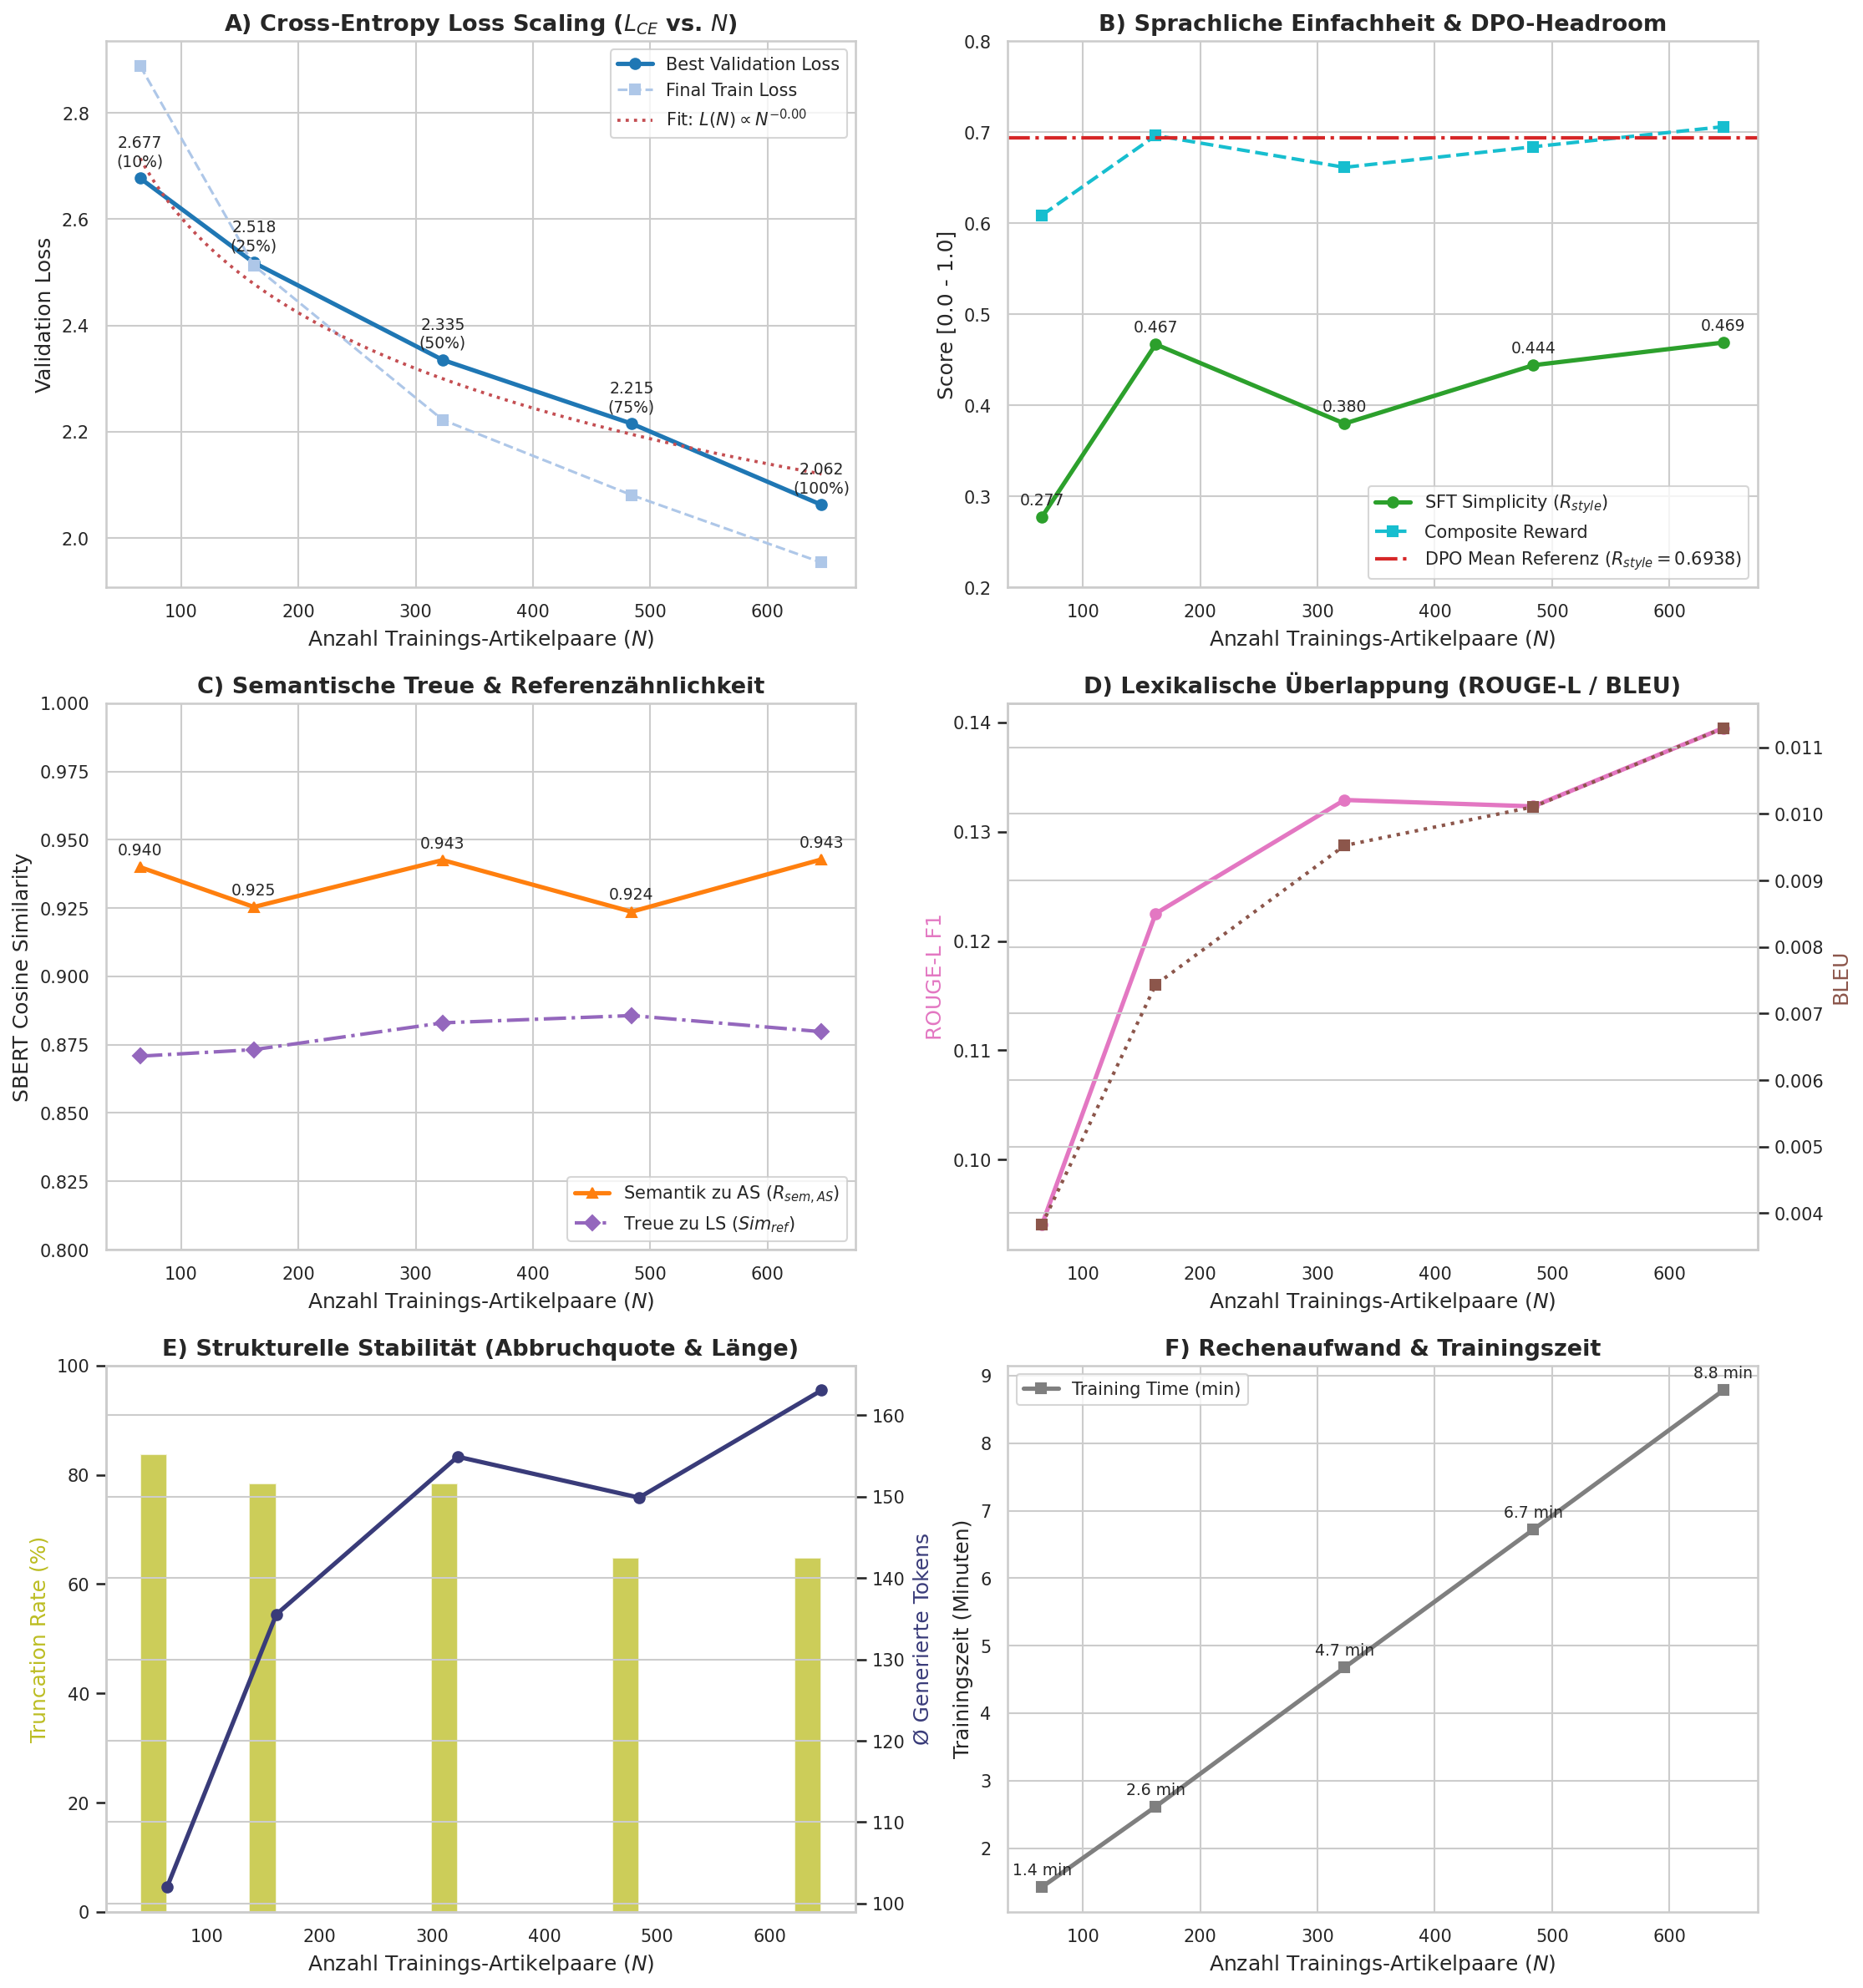

In [3]:
# ==============================================================================
# 3. MULTI-PANEL LEARNING CURVE & SCALING LAW PLOTS
# ==============================================================================
if not df.empty:
    fig, axes = plt.subplots(3, 2, figsize=(15, 16))
    
    x_vals = df["num_train_pairs"]
    fractions = [f"{int(f*100)}%" for f in df["train_fraction"]]
    
    # --------------------------------------------------------------------------
    # 1. Panel A: Cross-Entropy Loss Scaling (Validation & Train Loss)
    # --------------------------------------------------------------------------
    ax_loss = axes[0, 0]
    ax_loss.plot(x_vals, df["best_val_loss"], marker='o', linewidth=2.5, color='#1f77b4', label="Best Validation Loss")
    if "final_train_loss" in df.columns:
        ax_loss.plot(x_vals, df["final_train_loss"], marker='s', linestyle='--', color='#aec7e8', label="Final Train Loss")
        
    # Power-law Fit: L(N) = a * N^(-alpha) + b
    try:
        def power_law(x, a, alpha, b):
            return a * np.power(x, -alpha) + b
        popt, _ = curve_fit(power_law, x_vals, df["best_val_loss"], p0=[2.0, 0.3, 1.5], maxfev=5000)
        x_smooth = np.linspace(x_vals.min(), x_vals.max(), 100)
        ax_loss.plot(x_smooth, power_law(x_smooth, *popt), 'r:', linewidth=1.8, label=f"Fit: $L(N) \propto N^{{-{popt[1]:.2f}}}$")
    except Exception:
        pass
        
    ax_loss.set_title("A) Cross-Entropy Loss Scaling ($L_{CE}$ vs. $N$)", fontweight="bold")
    ax_loss.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_loss.set_ylabel("Validation Loss")
    ax_loss.legend(loc="upper right")
    for i, (x, y) in enumerate(zip(x_vals, df["best_val_loss"])):
        ax_loss.annotate(f"{y:.3f}\n({fractions[i]})", (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9)
        
    # --------------------------------------------------------------------------
    # 2. Panel B: Simplicity Score (R_style) & DPO-Headroom
    # --------------------------------------------------------------------------
    ax_simp = axes[0, 1]
    ax_simp.plot(x_vals, df["r_style_mean"], marker='o', linewidth=2.5, color='#2ca02c', label="SFT Simplicity ($R_{style}$)")
    ax_simp.plot(x_vals, df["composite_reward_mean"], marker='s', linewidth=2, linestyle='--', color='#17becf', label="Composite Reward")
    ax_simp.axhline(0.6938, color='#d62728', linestyle='-.', linewidth=2.0, label="DPO Mean Referenz ($R_{style}=0.6938$)")
    ax_simp.set_title("B) Sprachliche Einfachheit & DPO-Headroom", fontweight="bold")
    ax_simp.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_simp.set_ylabel("Score [0.0 - 1.0]")
    ax_simp.set_ylim(0.2, 0.8)
    ax_simp.legend(loc="lower right")
    for i, (x, y) in enumerate(zip(x_vals, df["r_style_mean"])):
        ax_simp.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9)
        
    # --------------------------------------------------------------------------
    # 3. Panel C: Semantik (AS) & LS-Referenztreue
    # --------------------------------------------------------------------------
    ax_sem = axes[1, 0]
    ax_sem.plot(x_vals, df["r_sem_as_mean"], marker='^', linewidth=2.5, color='#ff7f0e', label="Semantik zu AS ($R_{sem, AS}$)")
    ax_sem.plot(x_vals, df["sim_ref_mean"], marker='D', linewidth=2, linestyle='-.', color='#9467bd', label="Treue zu LS ($Sim_{ref}$)")
    ax_sem.set_title("C) Semantische Treue & Referenzähnlichkeit", fontweight="bold")
    ax_sem.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_sem.set_ylabel("SBERT Cosine Similarity")
    ax_sem.set_ylim(0.80, 1.00)
    ax_sem.legend(loc="lower right")
    for x, y in zip(x_vals, df["r_sem_as_mean"]):
        ax_sem.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9)
        
    # --------------------------------------------------------------------------
    # 4. Panel D: Lexikalische N-Gramm Metriken: BLEU & ROUGE-L
    # --------------------------------------------------------------------------
    ax_lex = axes[1, 1]
    ax_lex.plot(x_vals, df["rouge_l_mean"], marker='o', linewidth=2.5, color='#e377c2', label="ROUGE-L F1")
    ax_lex_twin = ax_lex.twinx()
    ax_lex_twin.plot(x_vals, df["bleu_mean"], marker='s', linewidth=2.0, linestyle=':', color='#8c564b', label="BLEU")
    ax_lex.set_title("D) Lexikalische Überlappung (ROUGE-L / BLEU)", fontweight="bold")
    ax_lex.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_lex.set_ylabel("ROUGE-L F1", color='#e377c2')
    ax_lex_twin.set_ylabel("BLEU", color='#8c564b')
    ax_lex.grid(False)
    
    # --------------------------------------------------------------------------
    # 5. Panel E: Satzabbruchquote & Generierte Textlänge
    # --------------------------------------------------------------------------
    ax_struct = axes[2, 0]
    ax_struct_twin = ax_struct.twinx()
    ax_struct.bar([x - 12 for x in x_vals], df["truncation_rate_pct"], width=24, color='#bcbd22', alpha=0.75, label="Truncation Rate (%)")
    ax_struct_twin.plot(x_vals, df["avg_gen_tokens"], marker='o', color='#393b79', linewidth=2.5, label="Ø Tokens")
    ax_struct.set_title("E) Strukturelle Stabilität (Abbruchquote & Länge)", fontweight="bold")
    ax_struct.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_struct.set_ylabel("Truncation Rate (%)", color='#bcbd22')
    ax_struct_twin.set_ylabel("Ø Generierte Tokens", color='#393b79')
    ax_struct.set_ylim(0, 100)
    ax_struct.grid(False)
    
    # --------------------------------------------------------------------------
    # 6. Panel F: Trainingszeit & Rechenaufwand (Wall-Clock Time)
    # --------------------------------------------------------------------------
    ax_time = axes[2, 1]
    ax_time.plot(x_vals, df["training_time_seconds"] / 60.0, marker='s', linewidth=2.5, color='#7f7f7f', label="Training Time (min)")
    ax_time.set_title("F) Rechenaufwand & Trainingszeit", fontweight="bold")
    ax_time.set_xlabel("Anzahl Trainings-Artikelpaare ($N$)")
    ax_time.set_ylabel("Trainingszeit (Minuten)")
    ax_time.legend(loc="upper left")
    for x, y in zip(x_vals, df["training_time_seconds"] / 60.0):
        ax_time.annotate(f"{y:.1f} min", (x, y), textcoords="offset points", xytext=(0, 7), ha='center', fontsize=9)
        
    plt.tight_layout()
    plot_file = os.path.join(PLOTS_DIR, "sft_scaling_comprehensive_curves.png")
    plt.savefig(plot_file, dpi=300)
    print(f"6-Panel Scaling Plot erfolgreich gespeichert unter: {plot_file}")
    plt.show()
else:
    print("Keine Daten fuer Plots vorhanden.")

## 3. Detaillierter Vergleich: SFT-Skalierungsplateau vs. DPO Alignment

Vergleichs-Plot gespeichert unter: results/experiments/sft_scaling/plots/sft_vs_dpo_comparison_bar.png


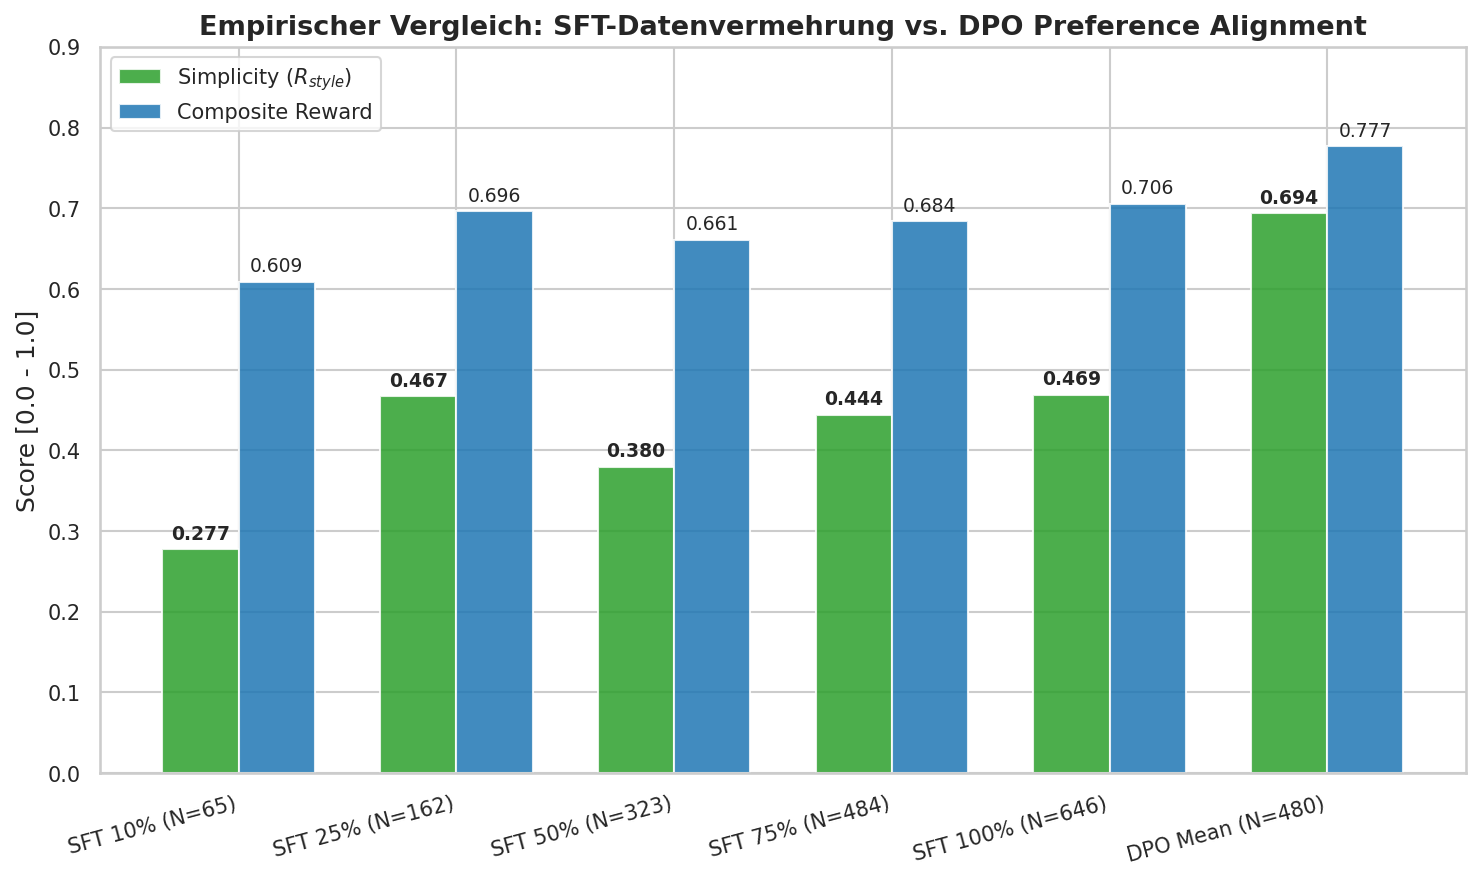

In [4]:
# ==============================================================================
# 4. RADAR / BALKEN-VERGLEICH: SFT SKALIERUNG VS. DPO ALIGNMENT
# ==============================================================================
if not df.empty:
    fig, ax = plt.subplots(figsize=(10, 6))
    
    models = [f"SFT {int(f*100)}% (N={n})" for f, n in zip(df["train_fraction"], df["num_train_pairs"])] + ["DPO Mean (N=480)"]
    simp_scores = list(df["r_style_mean"]) + [0.6938]
    comp_scores = list(df["composite_reward_mean"]) + [0.7767]
    
    x = np.arange(len(models))
    width = 0.35
    
    rects1 = ax.bar(x - width/2, simp_scores, width, label='Simplicity ($R_{style}$)', color='#2ca02c', alpha=0.85)
    rects2 = ax.bar(x + width/2, comp_scores, width, label='Composite Reward', color='#1f77b4', alpha=0.85)
    
    ax.set_ylabel('Score [0.0 - 1.0]')
    ax.set_title('Empirischer Vergleich: SFT-Datenvermehrung vs. DPO Preference Alignment', fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.set_ylim(0.0, 0.9)
    ax.legend(loc='upper left')
    
    # Werte über Balken
    for rect in rects1:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9, fontweight='bold')
    for rect in rects2:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=9)
                    
    plt.tight_layout()
    dpo_comp_file = os.path.join(PLOTS_DIR, "sft_vs_dpo_comparison_bar.png")
    plt.savefig(dpo_comp_file, dpi=300)
    print(f"Vergleichs-Plot gespeichert unter: {dpo_comp_file}")
    plt.show()

## 4. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)
Untersucht die linguistische Entwicklung der Übersetzungen von $10\%$ bis $100\%$ Trainingsdaten.

In [5]:
# ==============================================================================
# 5. QUALITATIVES AUDIT UEBER DIE SKALIERUNGSSTUFEN
# ==============================================================================
detail_files = sorted(glob.glob(os.path.join(RESULTS_DIR, "*_details.csv")))
if detail_files:
    dfs_det = [pd.read_csv(f) for f in detail_files]
    df_all_det = pd.concat(dfs_det, ignore_index=True)
    
    sample_as = df_all_det["as_text"].unique()[:2]
    for idx, as_query in enumerate(sample_as, 1):
        sub_df = df_all_det[df_all_det["as_text"] == as_query].sort_values(by="train_fraction")
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_query[:160]}...")
        print(f"[LS Referenz]: {ls_ref[:160]}...")
        print(f"{'-'*90}")
        
        for _, row in sub_df.iterrows():
            f_pct = int(row['train_fraction'] * 100)
            print(f"[{row['experiment_name']:20s} ({f_pct:3d}%)] (Simp: {row['r_style']:.3f} | Sem: {row['r_sem_as']:.3f} | Tokens: {row['gen_tokens']}):")
            print(f"  {row['generated_text']}\n")
else:
    print("Keine Detail-CSV Dateien verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (Wfb...
[LS Referenz]: Positionspapier: Bildung und Teilhabe am Arbeitsleben für Alle in einem inklusiven Arbeitsmarkt. Positionspapier bedeutet: Mehrere Gruppen haben diesen Text ges...
------------------------------------------------------------------------------------------
[sft_scale_f010       ( 10%)] (Simp: 0.082 | Sem: 0.990 | Tokens: 175):
  Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf di